<a href="https://colab.research.google.com/github/Ideas360/Talentotech-Inno-IA/blob/main/Lab_Pandas_Gemini_GOOGLE_API_KEY_Campista.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Laboratorio TECH: **Pandas + IA (Gemini con `GOOGLE_API_KEY`)**

> Mañana nos espera un **Laboratorio TECH**.  
> Vamos a aprender de forma sencilla y entretenida cómo usar **Pandas** para analizar datos con **modelos de Inteligencia Artificial**.  
> Tendremos **ejemplos guiados** y también momentos para que ustedes **experimenten y guarden su propio trabajo**.  
> La idea es que al final entiendan la teoría con la práctica, salgan con algo hecho por ustedes mismos y la **motivación para seguir creando**. 💡🔥

### ¿Qué haremos?
- Crear un pequeño mundo de datos (ventas de una tiendita) y analizarlo con **pandas**.
- Usar **Gemini** (vía `google-generativeai`) con tu **`GOOGLE_API_KEY`** para:
  - redactar **insights** a partir de agregados de pandas,
  - **clasificar** opiniones de clientes,
  - co‑crear **snippets** de matplotlib.
- Todo **100% práctico**, con explicaciones paso a paso.

In [ ]:
# ===============================
# 0) Instalación de librerías
# ===============================
# pandas: análisis de datos tabulares
# matplotlib: gráficas simples
# google-generativeai: cliente oficial de Gemini (Google)
!pip -q install pandas matplotlib google-generativeai

In [ ]:
# =============================================
# 1) Configurar tu GOOGLE_API_KEY (TU TURNO)
# =============================================
# Opción A (recomendada): define tu clave como variable de entorno en Colab.
#   - Ve a tu consola o al inicio del cuaderno y escribe:
#       %env GOOGLE_API_KEY=tu_clave_aqui
#
# Opción B: pegarla de forma oculta (no quedará visible en el cuaderno):
from getpass import getpass
import os
# Descomenta la siguiente línea para pegarla cuando corras la celda:
os.environ["GOOGLE_API_KEY"] = getpass("Pega tu GOOGLE_API_KEY aquí: ")

# Validar que existe una clave antes de seguir:
api_key = os.getenv("GOOGLE_API_KEY", "")
assert api_key, "⚠️ Define GOOGLE_API_KEY (con %env o getpass) antes de continuar."

# Configurar cliente de Gemini
import google.generativeai as genai
genai.configure(api_key=api_key)

# Elegimos un modelo rápido para taller
MODEL_NAME = "gemini-1.5-flash"
model = genai.GenerativeModel(MODEL_NAME)

# Helper para preguntar a la IA
def ask_gemini(prompt, temperature=0.6, json_mode=False):
    """
    Envia un prompt a Gemini y devuelve el texto de la respuesta.
    Si json_mode=True, se pide explicitamente que devuelva SOLO JSON.
    """
    if json_mode:
        prompt = prompt + "\n\nDevuelve SOLO JSON valido."
    response = model.generate_content(
        prompt,
        generation_config={"temperature": float(temperature)}
    )
    return response.text

Pega tu GOOGLE_API_KEY aquí: ··········


In [ ]:
# =============================================
# 2) Generar datasets de ejemplo (TU TURNO)
# =============================================
import pandas as pd
from datetime import datetime, timedelta
import random

# TODO: fija la semilla para reproducibilidad
random.seed(10)

# TODO: define lista de productos con (Producto, Categoría, PrecioLista, Costo)
productos = [
    ("Café", "Bebidas", 1.8, 0.9),
    ("Té Negro", "Bebidas", 1.5, 0.7),
    ("Jugo Naranja", "Bebidas", 2.0, 1.0),
    ("Sandwich Jamon y Queso", "Comida", 3.5, 1.5),
    ("Ensalada Cesar", "Comida", 5.0, 2.0),
    ("Galletas Chocolate", "Postres", 1.0, 0.5),
    ("Pastel Zanahoria", "Postres", 4.0, 1.8),
    ("Agua Mineral", "Bebidas", 1.2, 0.6),
    ("Papas Fritas", "Snacks", 2.5, 1.0),
    ("Brownie", "Postres", 3.0, 1.3),
    ("Refresco Cola", "Bebidas", 1.8, 0.9),
    ("Pizza Peperoni", "Comida", 12.0, 5.0),
    ("Hamburguesa Clásica", "Comida", 8.0, 3.0),
    ("Sushi Variado", "Comida", 15.0, 7.0),
    ("Smoothie Frutas", "Bebidas", 4.0, 1.5),
    ("Limonada Menta", "Bebidas", 3.0, 1.0),
    ("Muffin Arándanos", "Postres", 2.5, 1.0),
    ("Cheesecake Fresa", "Postres", 6.0, 2.5),
    ("Nachos Queso", "Snacks", 4.5, 2.0),
    ("Aros de Cebolla", "Snacks", 3.0, 1.2),
    ("Palomitas Maíz", "Snacks", 2.0, 0.8)
]

# TODO: conviértelo a DataFrame y guarda a 'productos.csv'
df_prod = pd.DataFrame(productos, columns=["Producto","Categoría","PrecioLista","Costo"])
df_prod.to_csv("productos.csv", index=False)

# TODO: crea clientes C001..C050 con segmentos A/B/C y guarda 'clientes.csv'
n_clientes = 50
clientes = [(f"C{i:03d}", random.choice(["A","B","C"])) for i in range(1, n_clientes+1)]
df_cli = pd.DataFrame(clientes, columns=["ClienteID","Segmento"])
df_cli.to_csv("clientes.csv", index=False)

# TODO: genera fechas desde 2025-01-01 por 60 días
fechas = [datetime(2025, 1, 1) + timedelta(days=i) for i in range(60)]

comentarios_pool = [
    "Muy buen sabor", "Llegó un poco frío", "Excelente, me encantó",
    "Precio justo", "Demoró en llegar", "Atención amable",
    "Porciones pequeñas", "Sabor consistente", "Recomendado",
    "No estuvo tan fresco", "Me sorprendió", "Volveré a comprar", None, None
]

rows = []
for f in fechas:
    for _ in range(random.randint(8, 16)):
        # completa aquí la lógica (elige producto/cliente/hora, simula nulos, etc.)
        producto = random.choice(productos)[0]
        cliente = random.choice(clientes)[0]
        hora = random.randint(8, 20)
        fecha_hora = f + timedelta(hours=hora, minutes=random.randint(0, 59), seconds=random.randint(0, 59))
        cantidad = random.randint(1, 5)
        precio = df_prod[df_prod["Producto"] == producto]["PrecioLista"].iloc[0]
        comentario = random.choice(comentarios_pool)

        rows.append({
            "FechaHora": fecha_hora,
            "ClienteID": cliente,
            "Producto": producto,
            "Cantidad": cantidad,
            "Precio": precio,
            "Comentario_cliente": comentario
        })


df = pd.DataFrame(rows)
df.to_csv("ventas.csv", index=False)
print("Archivos generados: ventas.csv, productos.csv, clientes.csv (filas ventas:", len(df), ")")
display(df.head())

Archivos generados: ventas.csv, productos.csv, clientes.csv (filas ventas: 736 )


,FechaHora,ClienteID,Producto,Cantidad,Precio,Comentario_cliente
0,2025-01-01 18:35:28,C021,Agua Mineral,4,1.2,Sabor consistente
1,2025-01-01 17:20:54,C042,Jugo Naranja,5,2.0,"Excelente, me encantó"
2,2025-01-01 11:02:02,C027,Agua Mineral,4,1.2,Demoró en llegar
3,2025-01-01 09:34:59,C043,Aros de Cebolla,1,3.0,"Excelente, me encantó"
4,2025-01-01 13:58:38,C037,Hamburguesa Clásica,2,8.0,Llegó un poco frío


In [ ]:
# =============================================
# 3) Cargar y explorar (TU TURNO)
# =============================================
import pandas as pd
df = pd.read_csv("ventas.csv")
df_prod = pd.read_csv("productos.csv")
df_cli = pd.read_csv("clientes.csv")
df["FechaHora"] = pd.to_datetime(df["FechaHora"])
df.info()
display(df.describe(include="all"))
df.isna().sum()
# df["Categoría"].value_counts() # This line caused the error
display(df_prod["Categoría"].value_counts()) # Access 'Categoría' from df_prod

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   FechaHora           736 non-null    datetime64[ns]
 1   ClienteID           736 non-null    object        
 2   Producto            736 non-null    object        
 3   Cantidad            736 non-null    int64         
 4   Precio              736 non-null    float64       
 5   Comentario_cliente  643 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 34.6+ KB


,FechaHora,ClienteID,Producto,Cantidad,Precio,Comentario_cliente
count,736,736,736,736.000000,736.000000,643
unique,NaN,50,21,NaN,NaN,12
top,NaN,C049,Sushi Variado,NaN,NaN,Volveré a comprar
freq,NaN,23,47,NaN,NaN,66
mean,2025-01-31 00:31:04.145380352,NaN,NaN,3.001359,4.275272,NaN
min,2025-01-01 08:34:45,NaN,NaN,1.000000,1.000000,NaN
25%,2025-01-16 17:11:27.500000,NaN,NaN,2.000000,2.000000,NaN
50%,2025-01-30 18:31:22,NaN,NaN,3.000000,3.000000,NaN
75%,2025-02-14 14:13:31.750000128,NaN,NaN,4.000000,5.000000,NaN
max,2025-03-01 20:32:49,NaN,NaN,5.000000,15.000000,NaN


,count
Categoría,
Bebidas,7
Comida,5
Postres,5
Snacks,4


In [ ]:
# =============================================
# 4) Limpieza + Features (TU TURNO)
# =============================================
df = df.dropna(subset=["Precio","Cantidad"]).copy()
df["Total"] = df["Precio"] * df["Cantidad"]
df["Dia"] = df["FechaHora"].dt.date.astype(str)
df["Hora"] = df["FechaHora"].dt.hour
df["Semana"] = df["FechaHora"].dt.isocalendar().week
df.head()

,FechaHora,ClienteID,Producto,Cantidad,Precio,Comentario_cliente,Total,Dia,Hora,Semana
0,2025-01-01 18:35:28,C021,Agua Mineral,4,1.2,Sabor consistente,4.8,2025-01-01,18,1
1,2025-01-01 17:20:54,C042,Jugo Naranja,5,2.0,"Excelente, me encantó",10.0,2025-01-01,17,1
2,2025-01-01 11:02:02,C027,Agua Mineral,4,1.2,Demoró en llegar,4.8,2025-01-01,11,1
3,2025-01-01 09:34:59,C043,Aros de Cebolla,1,3.0,"Excelente, me encantó",3.0,2025-01-01,9,1
4,2025-01-01 13:58:38,C037,Hamburguesa Clásica,2,8.0,Llegó un poco frío,16.0,2025-01-01,13,1


In [ ]:
# =============================================
# 5) GroupBy esenciales (TU TURNO)
# =============================================
df_merged = df.merge(df_prod, on="Producto", how="left")
ingresos_cat = df_merged.groupby("Categoría")["Total"].sum().sort_values(ascending=False)
ingresos_prod = df_merged.groupby("Producto")["Total"].sum().sort_values(ascending=False)
top5_u = df_merged.groupby("Producto")["Cantidad"].sum().sort_values(ascending=False).head(5)
ingresos_cat, ingresos_prod.head(), top5_u

(Categoría
 Comida     4895.0
 Postres    1912.0
 Bebidas    1467.8
 Snacks     1236.0
 Name: Total, dtype: float64,
 Producto
 Sushi Variado          2085.0
 Pizza Peperoni         1128.0
 Hamburguesa Clásica     880.0
 Cheesecake Fresa        822.0
 Ensalada Cesar          585.0
 Name: Total, dtype: float64,
 Producto
 Sushi Variado       139
 Cheesecake Fresa    137
 Muffin Arándanos    134
 Brownie             127
 Té Negro            124
 Name: Cantidad, dtype: int64)

In [ ]:
# =============================================
# 6) Pivot & Resample (TU TURNO)
# =============================================
tabla = pd.pivot_table(df_merged, index="Semana", columns="Categoría", values="Total", aggfunc="sum")
diario = df.set_index("FechaHora")["Total"].resample("D").sum()
tabla.head(), diario.head()

(Categoría  Bebidas  Comida  Postres  Snacks
 Semana                                     
 1            128.7   579.5    132.0    69.0
 2            170.0   671.5    160.0    97.0
 3            170.3   429.0    286.0   164.5
 4            173.6   682.5    194.5   148.0
 5            221.4   519.0    324.5   143.0,
 FechaHora
 2025-01-01    126.8
 2025-01-02    112.9
 2025-01-03    287.0
 2025-01-04    175.3
 2025-01-05    207.2
 Freq: D, Name: Total, dtype: float64)

In [ ]:
# =============================================
# 7) Joins (TU TURNO)
# =============================================
dfm = df.merge(df_prod, on="Producto", how="left")
dfm["MargenUnitario"] = dfm["Precio"] - dfm["Costo"]
dfm["Margen"] = dfm["MargenUnitario"] * dfm["Cantidad"]
dfm = dfm.merge(df_cli, on="ClienteID", how="left")
dfm.head()

,FechaHora,ClienteID,Producto,Cantidad,Precio,Comentario_cliente,Total,Dia,Hora,Semana,Categoría,PrecioLista,Costo,MargenUnitario,Margen,Segmento
0,2025-01-01 18:35:28,C021,Agua Mineral,4,1.2,Sabor consistente,4.8,2025-01-01,18,1,Bebidas,1.2,0.6,0.6,2.4,A
1,2025-01-01 17:20:54,C042,Jugo Naranja,5,2.0,"Excelente, me encantó",10.0,2025-01-01,17,1,Bebidas,2.0,1.0,1.0,5.0,B
2,2025-01-01 11:02:02,C027,Agua Mineral,4,1.2,Demoró en llegar,4.8,2025-01-01,11,1,Bebidas,1.2,0.6,0.6,2.4,B
3,2025-01-01 09:34:59,C043,Aros de Cebolla,1,3.0,"Excelente, me encantó",3.0,2025-01-01,9,1,Snacks,3.0,1.2,1.8,1.8,A
4,2025-01-01 13:58:38,C037,Hamburguesa Clásica,2,8.0,Llegó un poco frío,16.0,2025-01-01,13,1,Comida,8.0,3.0,5.0,10.0,A


In [ ]:
# =============================================
# 8) Ranking & Ventanas (TU TURNO)
# =============================================
res = df_merged.groupby(["Categoría","Producto"])["Total"].sum().reset_index()
res["RankCat"] = res.groupby("Categoría")["Total"].rank(ascending=False, method="dense")
res.sort_values(["Categoría","RankCat","Total"], inplace=True)
res.head(10)
diario = df.set_index("FechaHora")["Total"].resample("D").sum()
mm7 = diario.rolling(7).mean()

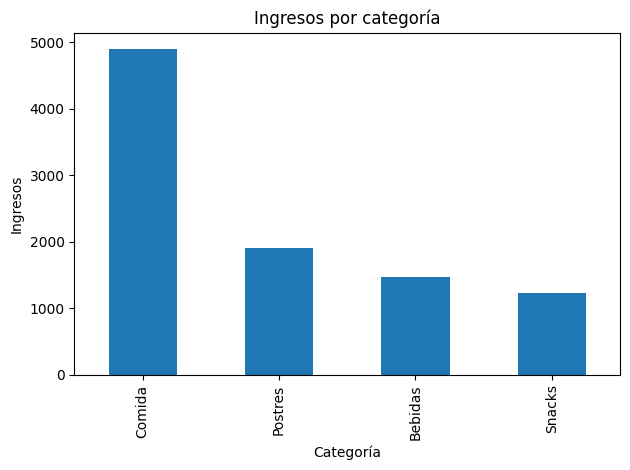

In [ ]:
# =============================================
# 9) Gráfica única (TU TURNO)
# =============================================
import matplotlib.pyplot as plt
serie = df_merged.groupby("Categoría")["Total"].sum().sort_values(ascending=False)
plt.figure()
serie.plot(kind="bar")
plt.title("Ingresos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Ingresos")
plt.tight_layout()
plt.show()

In [ ]:
# =============================================
# 10) IA — Insights desde pandas (TU TURNO)
# =============================================
resumen_cat = df_merged.groupby("Categoría")["Total"].sum().sort_values(ascending=False)
texto = resumen_cat.to_string()
prompt = f"""
Actúa como analista. Con estos datos agregados:
- Escribe 3 insights accionables (con verbo)
- Propón 2 hipótesis a validar
- Sugiere 2 visualizaciones simples (y por qué)
DATOS:
{texto}
"""
print(ask_gemini(prompt, temperature=0.5))

## Análisis de Datos de Ventas

**Datos:**

Categoría | Ventas
------- | --------
Comida     | 4895.0
Postres    | 1912.0
Bebidas    | 1467.8
Snacks     | 1236.0


**Insights Accionables:**

1. **Incrementar:**  la promoción de postres y bebidas para aumentar sus ventas y acercarse a los niveles de la categoría "Comida".  La diferencia significativa en ventas sugiere un potencial desaprovechado.
2. **Optimizar:** la estrategia de precios y ofertas para la categoría "Snacks", buscando mejorar su rentabilidad y  competitividad frente a las otras categorías. Su bajo rendimiento relativo requiere atención.
3. **Desarrollar:**  nuevos productos o promociones en la categoría "Snacks" para atraer a un público más amplio y aumentar su participación en las ventas totales.  La diferencia significativa con las otras categorías indica una necesidad de innovación o reposicionamiento.


**Hipótesis a Validar:**

1. **Hipótesis de Precio:**  Un ajuste de precios en la categoría "Snacks" (por ejemplo,

In [ ]:
# =============================================
# 11) IA — Clasificar comentarios (TU TURNO, salida JSON)
# =============================================
comentarios = "\n".join(df["Comentario_cliente"].dropna().tolist())
prompt = f"""
Clasifica cada comentario en positivo, negativo o neutral.
Devuelve SOLO un bloque de JSON válido dentro de triples comillas invertidas (```json ... ```).

COMENTARIOS:
{comentarios}
"""
salida = ask_gemini(prompt, temperature=0.3, json_mode=False) # json_mode=True was causing the model to add extra text
print(salida)
import json
import re

# Extract JSON from the response
json_match = re.search(r"```json\n(.*?)\n```", salida, re.DOTALL)
if json_match:
    json_string = json_match.group(1)
    try:
        data = json.loads(json_string)
        print("Keys in the JSON response:", list(data.keys()))
    except json.JSONDecodeError as e:
        print("Failed to decode JSON after extraction:", e)
else:
    print("No JSON block found in the response.")
    # Fallback if no ```json block is found, try to parse the whole response
    try:
        data = json.loads(salida)
        print("Keys in the JSON response (fallback):", list(data.keys()))
    except json.JSONDecodeError as e:
        print("Failed to decode JSON from raw response:", e)

```json
{
  "comentarios": [
    {"comentario": "Sabor consistente", "clasificacion": "positivo"},
    {"comentario": "Excelente, me encantó", "clasificacion": "positivo"},
    {"comentario": "Demoró en llegar", "clasificacion": "negativo"},
    {"comentario": "Excelente, me encantó", "clasificacion": "positivo"},
    {"comentario": "Llegó un poco frío", "clasificacion": "negativo"},
    {"comentario": "Porciones pequeñas", "clasificacion": "negativo"},
    {"comentario": "No estuvo tan fresco", "clasificacion": "negativo"},
    {"comentario": "Excelente, me encantó", "clasificacion": "positivo"},
    {"comentario": "Atención amable", "clasificacion": "positivo"},
    {"comentario": "Atención amable", "clasificacion": "positivo"},
    {"comentario": "No estuvo tan fresco", "clasificacion": "negativo"},
    {"comentario": "Volveré a comprar", "clasificacion": "positivo"},
    {"comentario": "Llegó un poco frío", "clasificacion": "negativo"},
    {"comentario": "Porciones pequeñas", "cla

In [ ]:
# =============================================
# 12) IA — Copiloto de código Matplotlib (TU TURNO)
# =============================================
contexto = "Quiero graficar mi serie 'serie' de ingresos por categoría."
prompt = f"""
Con este contexto: {contexto}
Devuélveme SOLO un snippet de Python listo para pegar en Colab que:
- Use matplotlib
- Una sola figura
- Sin estilos ni colores personalizados
- Con título, ejes y 'tight_layout()'
"""
print(ask_gemini(prompt))

```python
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6)) # Ajusta el tamaño si es necesario
plt.plot(serie)
plt.title('Ingresos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.show()

```



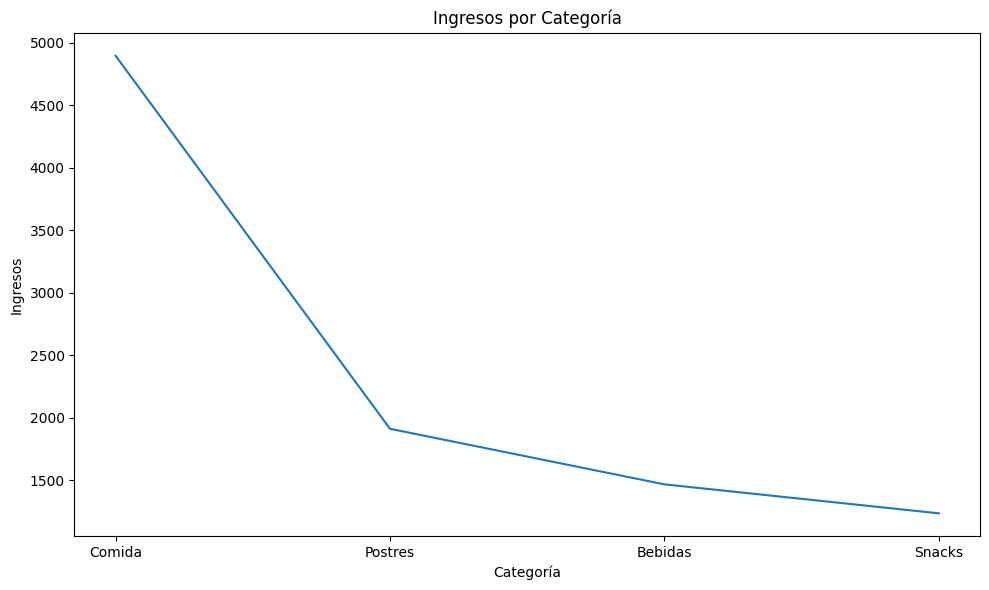

In [ ]:
plt.figure(figsize=(10, 6)) # Ajusta el tamaño si es necesario
plt.plot(serie)
plt.title('Ingresos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ingresos')
plt.tight_layout()
plt.show()

## 13) Retos creativos (opcionales)
1) **Outliers (IQR)**: detecta días anómalos de ingreso.  
2) **Cohortes simples**: primer mes de compra por cliente y gasto total.  
3) **Franjas horarias**: Mañana/Tarde/Noche y top categoría por franja.

## 14) Cierre
- Un hallazgo con `groupby`/`pivot` y por qué importa.  
- Qué limpiaste y por qué fue razonable.  
- Una idea propuesta por la IA que valga la pena testear.